In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

In [27]:
df_avisos = pd.read_csv("./dados_ondas_calor.csv")
df_sia = pd.read_csv("./dados_sia_total_filtrados.csv")
df_avisos['municipio'] = df_avisos['codigo_ibge_municipio'].astype(str).str[:6]
df_sia['municipio'] = df_sia['PA_MUNPCN'].astype(str).str[:6]

In [29]:
df_sia['PA_CMP_str'] = df_sia['PA_CMP'].astype(str)
df_sia['ano'] = df_sia['PA_CMP_str'].str[:4].astype(int)
df_sia['mes'] = df_sia['PA_CMP_str'].str[4:6].astype(int)

In [30]:
df_sia.query("municipio == '110001' and ano == 2022 and mes == 5")

,Unnamed: 0,UF,PA_MUNPCN,PA_CMP,PA_QTDPRO,PA_QTDAPR,municipio,PA_CMP_str,ano,mes
59259,59259,BA,110001,202205,90,90,110001,202205,2022,5
159289,159289,RO,110001,202205,11,11,110001,202205,2022,5


In [5]:
df_avisos = df_avisos.query("ano >= 2022 and ano <= 2024")
df_sia = df_sia.query("ano >= 2022 and ano <= 2024")

In [6]:
df_avisos['data'] = pd.to_datetime(df_avisos['data_envio']).dt.tz_localize(None).dt.normalize()

### Agrupar por mês o total de dias com pelo menos 1 aviso

In [7]:
df_avisos['dia'] = df_avisos['data'].dt.day
dias_com_aviso = df_avisos.groupby(['municipio', 'ano', 'mes'])['dia'].nunique().reset_index()
dias_com_aviso.rename(columns={'dia': 'total_dias_com_aviso'}, inplace=True)

In [8]:
dias_por_severidade = df_avisos.groupby(['municipio', 'ano', 'mes', 'severidade'])['dia'].nunique().reset_index()
dias_por_severidade.rename(columns={'dia': 'total_dias_com_aviso'}, inplace=True)

In [9]:
dias_por_severidade_pivot = dias_por_severidade.pivot_table(
    index=['municipio', 'ano', 'mes'],
    columns='severidade',
    values='total_dias_com_aviso',
    fill_value=0
).reset_index()


### Agrupar os atendimentos produzidos por mes e realizar o join com tabela de avisos

In [ ]:
atendimentos_agrupados = df_sia.groupby(['municipio', 'ano', 'mes'])['PA_QTDPRO'].sum().reset_index(name='qtd_axtendimentos')

df_full_1 = pd.merge(
    atendimentos_agrupados, 
    dias_com_aviso,
    on=['municipio', 'ano', 'mes'],
    how='left'
).merge(
    dias_por_severidade_pivot,
    on=['municipio', 'ano', 'mes'],
    how='left'
)

df_full_1[['total_dias_com_aviso'] + list(dias_por_severidade_pivot.columns[3:])] = \
    df_full_1[['total_dias_com_aviso'] + list(dias_por_severidade_pivot.columns[3:])].fillna(0)


### Adicionando regiões de saúde

In [11]:
df_regioes_saude = pd.read_csv("./dados/macroregiao_de_saude.csv", sep=";")
df_regioes_saude = df_regioes_saude[['sg_uf', 'co_uf', 'cod_macrorregiao_de_saude', 'regiao_de_saude', 'macrorregiao_de_saude', 'cod_municipio']]
df_regioes_saude.columns = ['sg_uf', 'co_uf', 'cod_macrorregiao_de_saude', 'regiao_de_saude', 'macrorregiao_de_saude', 'municipio']

In [12]:
df_full_1['municipio'] = df_full_1['municipio'].astype(int)
df_regioes_saude['municipio'] = df_regioes_saude['municipio'].astype(int)


df_full = pd.merge(
    df_full_1,
    df_regioes_saude,
    on=['municipio'],
    how='inner'
)

In [13]:
len(df_full)

147589

In [14]:
corr = df_full['qtd_atendimentos'].corr(df_full['total_dias_com_aviso'])
print(f'Correlação entre atendimentos cardiovasculares e dias com aviso: {corr:.3f}')


Correlação entre atendimentos cardiovasculares e dias com aviso: 0.023


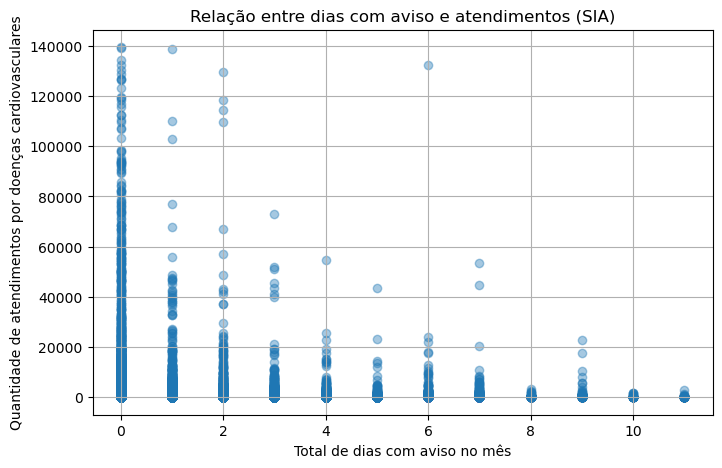

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df_full['total_dias_com_aviso'], df_full['qtd_atendimentos'], alpha=0.4)
plt.xlabel('Total de dias com aviso no mês')
plt.ylabel('Quantidade de atendimentos por doenças cardiovasculares')
plt.title('Relação entre dias com aviso e atendimentos (SIA)')
plt.grid(True)
plt.show()


#### Modelagem

In [16]:
import statsmodels.formula.api as smf

md = smf.mixedlm(
    "qtd_atendimentos ~ total_dias_com_aviso",  
    df_full,                                   
    groups=df_full["cod_macrorregiao_de_saude"]      
)
mdf = md.fit()
print(mdf.summary())


               Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   qtd_atendimentos
No. Observations:   147589    Method:               REML            
No. Groups:         120       Scale:                8902639.5346    
Min. group size:    28        Log-Likelihood:       -1390439.5603   
Max. group size:    4406      Converged:            Yes             
Mean group size:    1229.9                                          
--------------------------------------------------------------------
                       Coef.    Std.Err.   z   P>|z|  [0.025  0.975]
--------------------------------------------------------------------
Intercept               333.403   45.218 7.373 0.000 244.777 422.029
total_dias_com_aviso     47.853    8.351 5.730 0.000  31.486  64.221
Group Var            218995.372   10.046                            



In [17]:
import numpy as np

md = smf.mixedlm(
    "qtd_atendimentos ~ C(ano) + C(mes)",
    df_full,
    groups=df_full["cod_macrorregiao_de_saude"]
)
mdf = md.fit()
print(mdf.summary())

             Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: qtd_atendimentos
No. Observations:  147589  Method:             REML            
No. Groups:        120     Scale:              8888718.9909    
Min. group size:   28      Log-Likelihood:     -1390266.3033   
Max. group size:   4406    Converged:          Yes             
Mean group size:   1229.9                                      
---------------------------------------------------------------
                 Coef.    Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------
Intercept         141.824   53.372  2.657 0.008  37.217 246.431
C(ano)[T.2023]    123.241   19.190  6.422 0.000  85.628 160.853
C(ano)[T.2024]    289.119   19.046 15.180 0.000 251.790 326.448
C(mes)[T.2]        -5.492   38.384 -0.143 0.886 -80.723  69.740
C(mes)[T.3]        14.485   38.266  0.379 0.705 -60.515  89.484
C(mes)[T.4]        25.382   38.291  0.663 0.507 -49.6

In [18]:
formula = 'qtd_atendimentos ~  Extreme + Moderate + Severe'
import statsmodels.formula.api as smf
modelo = smf.mixedlm(formula, df_full, groups=df_full['cod_macrorregiao_de_saude'])
resultado = modelo.fit()
print(resultado.summary())


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: qtd_atendimentos
No. Observations: 147589  Method:             REML            
No. Groups:       120     Scale:              8902440.4309    
Min. group size:  28      Log-Likelihood:     -1390428.5083   
Max. group size:  4406    Converged:          Yes             
Mean group size:  1229.9                                      
---------------------------------------------------------------
             Coef.     Std.Err.    z    P>|z|   [0.025   0.975]
---------------------------------------------------------------
Intercept     332.763    45.217  7.359  0.000  244.139  421.387
Extreme        53.687    19.308  2.781  0.005   15.845   91.530
Moderate       48.890    20.708  2.361  0.018    8.304   89.476
Severe         23.608    18.889  1.250  0.211  -13.415   60.631
Group Var  218979.233    10.048                                



In [19]:
print("Média atendimentos com qualquer aviso:", 
      round(df_full[df_full['total_dias_com_aviso'] > 0]['qtd_atendimentos'].mean(),2))
print("Média atendimentos sem aviso:", 
      round(df_full[df_full['total_dias_com_aviso'] == 0]['qtd_atendimentos'].mean(),2))

Média atendimentos com qualquer aviso: 670.74
Média atendimentos sem aviso: 448.25


In [20]:
print("Média atendimentos com aviso extremo:", 
      round(df_full[df_full['Extreme'] > 0 ]['qtd_atendimentos'].mean(),2))
print("Média atendimentos com aviso severo:", 
      round(df_full[df_full['Severe'] > 0]['qtd_atendimentos'].mean(),2))
print("Média atendimentos com aviso moderado:", 
      round(df_full[df_full['Moderate'] > 0]['qtd_atendimentos'].mean(),2))

Média atendimentos com aviso extremo: 880.81
Média atendimentos com aviso severo: 705.58
Média atendimentos com aviso moderado: 686.54
